# How to think about STREAM

STREAM solves `M dy/dt = F(y, t)` for a system assembled from pieces. The pieces are Calculations, each owning a slice of `y` and its rows of `F`. The Aggregator assembles them as a graph that routes values between them, and the State is `y` read back by name. Typical systems are reactor loops with channels, fuel plates, pumps, valves and point kinetics.

In [1]:
%matplotlib inline
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stream.calculations import (ChannelAndContacts, Fuel, Gravity, HeatExchanger, Junction, KirchhoffWDerivatives,
                                 Pump, Resistor, Solid)
from stream.composition import (FlowGraph, check_gravity_mismatch, flow_edge, guess_steady_state, symmetric_plate,
                                uniform_x_power_shape, x_boundaries)
from stream.jacobians import ALG_jacobian, DAE_jacobian
from stream.physical_models.heat_transfer_coefficient import wall_heat_transfer_coeff
from stream.pipe_geometry import EffectivePipe
from stream.substances import light_water

from showcase import plots

## A Calculation

A `Pump` is built from a head or a flow, never both.

In [2]:
print(inspect.signature(Pump))
pump_demo = Pump(pressure=1e4, name="Pump")
pd.DataFrame({"place in slice": list(pump_demo.variables.values()), "differential": pump_demo.mass_vector},
             index=list(pump_demo.variables))

(pressure: float | numpy.ndarray | None = None, mdot0: float | numpy.ndarray | None = None, name: str = 'Pump')


,place in slice,differential
Tin,0,False
pressure,1,False


It owns two entries, both algebraic: `Tin`, the temperature it hands downstream, and `pressure`, its Δp. `calculate` reads the flow and the temperatures arriving from either side and returns two residuals: outlet minus inlet temperature, and Δp minus the head.

In [3]:
print(inspect.signature(Pump.calculate))

(self, variables: Sequence[float], *, mdot: float | numpy.ndarray, Tin: float | numpy.ndarray, Tin_minus: float | numpy.ndarray | None = None, pressure: float | numpy.ndarray | None = None, mdot0: float | numpy.ndarray | None = None, **_) -> numpy.ndarray


## The Aggregator

A toy loop: pump from A to B, resistor back. `FlowGraph` adds a `Kirchhoff` node for the flows; each node owns a contiguous slice of `y`.

In [4]:
j_a, j_b = Junction(name="J_a"), Junction(name="J_b")
toy_pump, toy_res = Pump(pressure=1e4, name="Pump"), Resistor(resistance=1e4, name="Resistor")
toy = FlowGraph(flow_edge((j_a, j_b), toy_pump), flow_edge((j_b, j_a), toy_res)).aggregator
print("len(toy) =", len(toy))
for node, sl in toy.sections.items():
    print(f"{node.name:10s} {type(node).__name__:10s} {sl}")

len(toy) = 8
J_a        Junction   slice(0, 1, None)
Pump       Pump       slice(1, 3, None)
J_b        Junction   slice(3, 4, None)
Resistor   Resistor   slice(4, 6, None)
Kirchhoff  Kirchhoff  slice(6, 8, None)


Edges carry named variables. What flows into the pump:

In [5]:
for src, _, data in toy.graph.in_edges(toy_pump, data=True):
    print(f"{src.name:10s} -> Pump  {data['variables']}")

J_a        -> Pump  ('Tin',)
J_b        -> Pump  ('Tin_minus',)
Kirchhoff  -> Pump  ('mdot',)


## The State

`save` turns a vector into a nested dict by calculation and variable, `load` turns it back. Feeding `0, 1, 2, ...` shows where each entry lives.

In [6]:
state = toy.save(np.arange(len(toy), dtype=float))
print(state)
print("round trip:", np.array_equal(toy.load(state), np.arange(len(toy))))
state.to_dataframe()

{'J_a': {'Tin': np.float64(0.0)}, 'Pump': {'Tin': np.float64(1.0), 'pressure': np.float64(2.0)}, 'J_b': {'Tin': np.float64(3.0)}, 'Resistor': {'Tin': np.float64(4.0), 'pressure': np.float64(5.0)}, 'Kirchhoff': {'(J_a -> J_b, 0)': np.float64(6.0), '(J_b -> J_a, 0)': np.float64(7.0)}}
round trip: True


,calculation,variable,i,j,value
0,J_a,Tin,0,0,0.0
1,Pump,Tin,0,0,1.0
2,Pump,pressure,0,0,2.0
3,J_b,Tin,0,0,3.0
4,Resistor,Tin,0,0,4.0
5,Resistor,pressure,0,0,5.0
6,Kirchhoff,"(J_a -> J_b, 0)",0,0,6.0
7,Kirchhoff,"(J_b -> J_a, 0)",0,0,7.0


## A heated loop

One plate channel, 0.7 m long with a 2 mm gap, pumped downward and returned through a heat exchanger at 40 °C, at 2 bar.

In [7]:
TIN, P_REF, L, WIDTH, GAP, N = 40.0, 2e5, 0.7, 0.070, 0.002, 10
DP_PUMP, POWER = 5e3, 3e3
Z = np.linspace(0.0, L, N + 1)

The channel is a 1-D coolant column with a wall on each face; it stops the solve if its bulk saturates.

In [8]:
channel = ChannelAndContacts(z_boundaries=Z, fluid=light_water, h_wall_func=wall_heat_transfer_coeff,
                             pipe=EffectivePipe.rectangular(length=L, edge1=WIDTH, edge2=GAP, heated_edge=WIDTH),
                             stop_at_saturation=True, name="Channel")

The plate is a 2-D conduction grid, aluminium cladding around a fuel meat, 10 cells high and 12 across.

In [9]:
meat = np.zeros((N, 12), dtype=bool)
meat[:, 2:-2] = True
materials = np.where(meat, Solid(density=3500, specific_heat=750, conductivity=40),
                     Solid(density=2700, specific_heat=900, conductivity=167))
fuel = Fuel(z_boundaries=Z, x_boundaries=x_boundaries(2, 8, 0.0005, 0.0006), material=Solid.from_array(materials),
            meat_indices=meat, power_shape=uniform_x_power_shape(N, 8, 2, 0.0005, 0.0006, WIDTH), y_length=WIDTH,
            name="Fuel")

The return leg climbs, so its `Gravity` disposition is negative (positive is downward). Two heat exchangers sandwich it so its column stays at 40 °C in either flow direction; a single one cannot guarantee that after reversal.

In [10]:
j_top, j_bot = Junction(name="J_top"), Junction(name="J_bot")
pump = Pump(pressure=DP_PUMP, name="Pump")
hx_in, hx_out = HeatExchanger(outlet=TIN, name="HX_in"), HeatExchanger(outlet=TIN, name="HX_out")
gravity = Gravity(fluid=light_water, disposition=-L, name="Gravity")

`FlowGraph` builds the Kirchhoff network; `check_gravity_mismatch` confirms the loop closes hydrostatically at zero flow, silently here.

In [11]:
fg = FlowGraph(flow_edge((j_top, j_bot), channel), flow_edge((j_bot, j_top), pump, hx_in, gravity, hx_out),
               inertial_comps=[channel], k_constructor=KirchhoffWDerivatives, abs_pressure_comps=[channel],
               reference_node=(j_top, P_REF))
K = fg.kirchhoff
check_gravity_mismatch(K)

`symmetric_plate` couples plate and channel on both faces. Aggregators add; the plate power enters through `funcs`.

In [12]:
agr = fg.aggregator + symmetric_plate(channel, fuel, funcs={fuel: {"power": POWER}}).to_aggregator()
sizes = {n.name: agr.sections[n].stop - agr.sections[n].start for n in agr.graph}
print("len(agr) =", len(agr), sizes)

len(agr) = 186 {'J_top': 1, 'Channel': 31, 'J_bot': 1, 'Pump': 2, 'HX_in': 2, 'Gravity': 2, 'HX_out': 2, 'Kirchhoff': 5, 'Fuel': 140}


## Steady first

A transient must start where `F = 0`, or its first instants are the solver repairing the start. `guess_steady_state` builds a guess from the pump flow; `solve_steady` finishes it.

In [13]:
guess = agr.load(guess_steady_state(agr, K, flows={pump: 0.2}))
y_steady = agr.solve_steady(guess, jac=ALG_jacobian(agr))
for label, y in (("guess", guess), ("steady", y_steady)):
    print(f"{label:7s} |F| = {np.linalg.norm(agr.compute(y, 0.0)):.2g}")
steady = agr.save(y_steady)
print(f"flow {steady[K.name][K.component_edge(channel)]:.3f} kg/s, outlet {steady['Channel']['T_cool'][-1]:.1f} °C")

guess   |F| = 0.014
steady  |F| = 1.2e-10
flow 0.179 kg/s, outlet 44.0 °C


## A transient

The pump head falls to zero along a half cosine between 1 and 2 s, set through `agr.funcs`; IDA integrates 200 s.

In [14]:
def head(t):
    return DP_PUMP if t <= 1.0 else 0.0 if t >= 2.0 else 0.5 * DP_PUMP * (1 + np.cos(np.pi * (t - 1.0)))


agr.funcs.setdefault(pump, {})["pressure"] = head
sol = agr.solve(y_steady, time=np.linspace(0.0, 200.0, 801), jacfn=DAE_jacobian(agr),
                atol=agr.scaled_atol(1e-4), rtol=1e-4)
print("status:", sol.status.name)

status: COMPLETED


Flow reverses at about 5 s into natural circulation, upward through the channel. The outlet moves from the bottom cell to the top, which overshoots to about 87 °C and settles near 82 °C. The run is flat after about 30 s.

t = 200 s: flow -0.0169 kg/s, top 82.4 °C, peak 87.4 °C


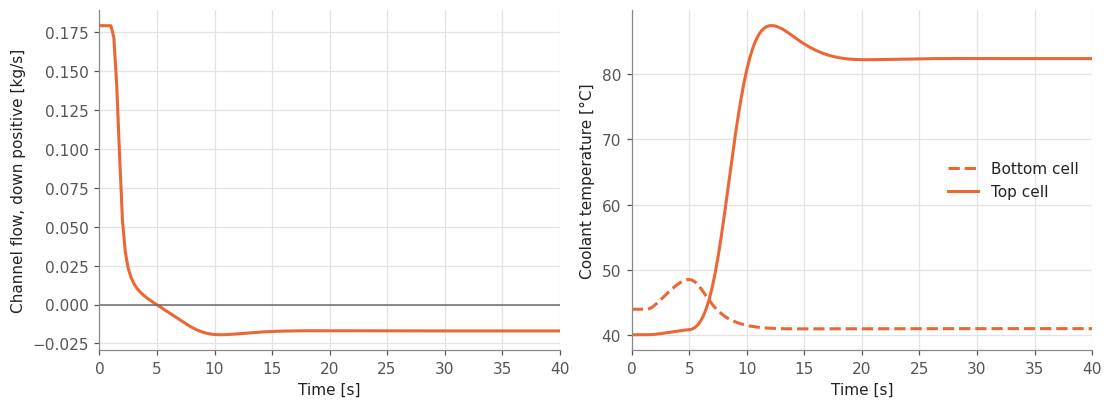

In [15]:
t = np.asarray(sol.time)
mdot = agr.at_times(sol, K, K.component_edge(channel))
T_cool = agr.at_times(sol, channel, "T_cool")
with plots.style():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
    axes[0].plot(t, mdot, color=plots.COLORS["hot"])
    axes[0].axhline(0.0, color=plots.NEUTRAL, linewidth=1.0)
    axes[0].set(xlim=(0, 40), xlabel="Time [s]", ylabel="Channel flow, down positive [kg/s]")
    axes[1].plot(t, T_cool[:, -1], color=plots.COLORS["hot"], linestyle="--", label="Bottom cell")
    axes[1].plot(t, T_cool[:, 0], color=plots.COLORS["hot"], label="Top cell")
    axes[1].set(xlim=(0, 40), xlabel="Time [s]", ylabel="Coolant temperature [°C]")
    axes[1].legend()
print(f"t = {t[-1]:.0f} s: flow {mdot[-1]:.4f} kg/s, top {T_cool[-1, 0]:.1f} °C, peak {T_cool[:, 0].max():.1f} °C")

## When it goes wrong

Every STREAM error names what failed; `show` prints it with the notes the solver attaches.

In [16]:
def show(e):
    print(type(e).__name__)
    print(e)
    print(getattr(e, "__notes__", []))

A return leg with the wrong sign: both columns push the same way, so at zero flow the loop is off by about 14 kPa, twice `ρ g L`.

In [17]:
a, b = Junction(name="J_top"), Junction(name="J_bot")
bad = FlowGraph(
    flow_edge((a, b), Pump(pressure=1e4, name="Pump"), Gravity(fluid=light_water, disposition=L, name="Down")),
    flow_edge((b, a), Resistor(resistance=1e4, name="Resistor"), Gravity(fluid=light_water, disposition=L, name="Up")))
try:
    check_gravity_mismatch(bad.kirchhoff)
except Exception as e:
    show(e)

GravityMismatchError
There are unclosed loops when flows are 0.
The following is a report of those loop components and their aggregate pressure difference (in head = 1.0 [Pascal]):
[([Pump, Down, Resistor, Up], 13735.919866465016)]
[]


A misspelled `funcs` key: the plate's power given as `powr`.

In [18]:
try:
    symmetric_plate(channel, fuel, funcs={fuel: {"powr": POWER}}).to_aggregator()
except Exception as e:
    show(e)

StreamConstructionError
Fuel's calculate cannot accept wired variable(s) ['powr']: it has no such parameter and no **kwargs, so the routed value(s) would be a TypeError at compute. Fuel's calculate accepts ['T_bottom', 'T_left', 'T_right', 'T_top', 'h_bottom', 'h_left', 'h_right', 'h_top', 'power', 'variables']. Fix the edge/funcs variable name, or give calculate a matching parameter.
[]


Three times the power. Under forced flow the outlet sits near 52 °C, far below saturation at about 120 °C; by about 5.3 s the flow has turned upward at about 0.02 kg/s and the bulk reaches saturation.

In [19]:
agr.funcs[fuel]["power"] = 3 * POWER
y_hot = agr.solve_steady(agr.load(guess_steady_state(agr, K, flows={pump: 0.2})), jac=ALG_jacobian(agr))
print(f"steady outlet {agr.save(y_hot)['Channel']['T_cool'][-1]:.1f} °C, "
      f"Tsat {float(light_water.sat_temperature(P_REF)):.1f} °C")
try:
    agr.solve(y_hot, time=np.linspace(0.0, 200.0, 801), jacfn=DAE_jacobian(agr), atol=agr.scaled_atol(1e-4),
              rtol=1e-4)
except Exception as e:
    show(e)
    last = agr.state_from(e.y[-1])
    print(f"stopped at t = {e.t[-1]:.2f} s, channel flow {last[K.name][K.component_edge(channel)]:.4f} kg/s")

steady outlet 51.9 °C, Tsat 120.3 °C


SaturationReachedError
Channel 'Channel' reached saturation: bulk coolant in cell(s) [3] is at/above Tsat (worst cell 3: T_bulk=120.72°C >= Tsat=120.72°C). STREAM's single-phase model ends at bulk saturation — two-phase flow is not modelled — so the solve was stopped here. Reduce power, raise pressure, or increase flow to keep the channel subcooled.
["while evaluating Calculation 'Channel' (ChannelAndContacts).change_state at t=5.312891432746196"]
stopped at t = 5.31 s, channel flow -0.0237 kg/s


Each message points at a component and where in it the trouble sits; the saturation stop also keeps the valid trajectory.

## Where to read next

The second notebook trips the pump of a four-channel loop and follows it into natural circulation. `docs/source/failure_modes.md` explains every way a solve stops; the `stream.composition` and `stream.aggregator` API pages cover `FlowGraph` and `Aggregator.solve`.